In [1]:
#hello
#6 hour rainfall over 1 in
#24 hour snowfall over 2 in
#wind gusts over 58 mph
#1 hour qpf >.50 in
#wind chill <10 F
#vis <.25 mile

# Preliminary Thoughts
We are going to be focusing on storms in the State College area, and how they have a chance to cancel IM activities. We are interested in exploring this because of the famous video of a student getting hit with a porta-potty, due to these hazordous conditions. It is useful to quantify these threats because it can be dangerous to travel to the IM when hazordous condtions are in the area. 

### Group contributions
Number's 2,3, and 4 have been mostly Ivan's code, but Michael and Flip had another set of eyes on it to help Ivan

# Map descriptions:

1. This map shows validation of pressure systems nation wide during the date and time of our event. There is a massive front that hosts multiple low pressure systems that sweep through Delaware all the way to Texas. This map also shows that Pennsylvania has mixed pricipitation, with rain just south of PA from these low pressure systems.
2. This map shows radar data from 8pm EDT for Pennsylvania. Many rounds of precipiation sweep through PA into NY and all the way to NE.
3. This map shows the 24 hr precipiation totals throughout the USA ending Monday, 3/23 at 7am. Most of central and northern PA have experienced measurable rainfall.

Overall, these maps show weather events that could create a hazard for IM sports activities.

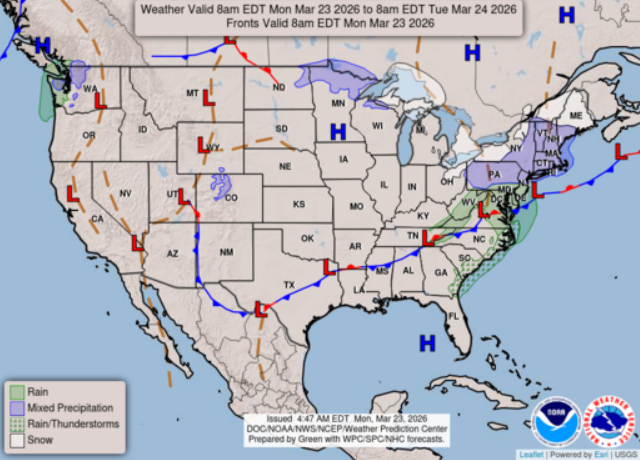

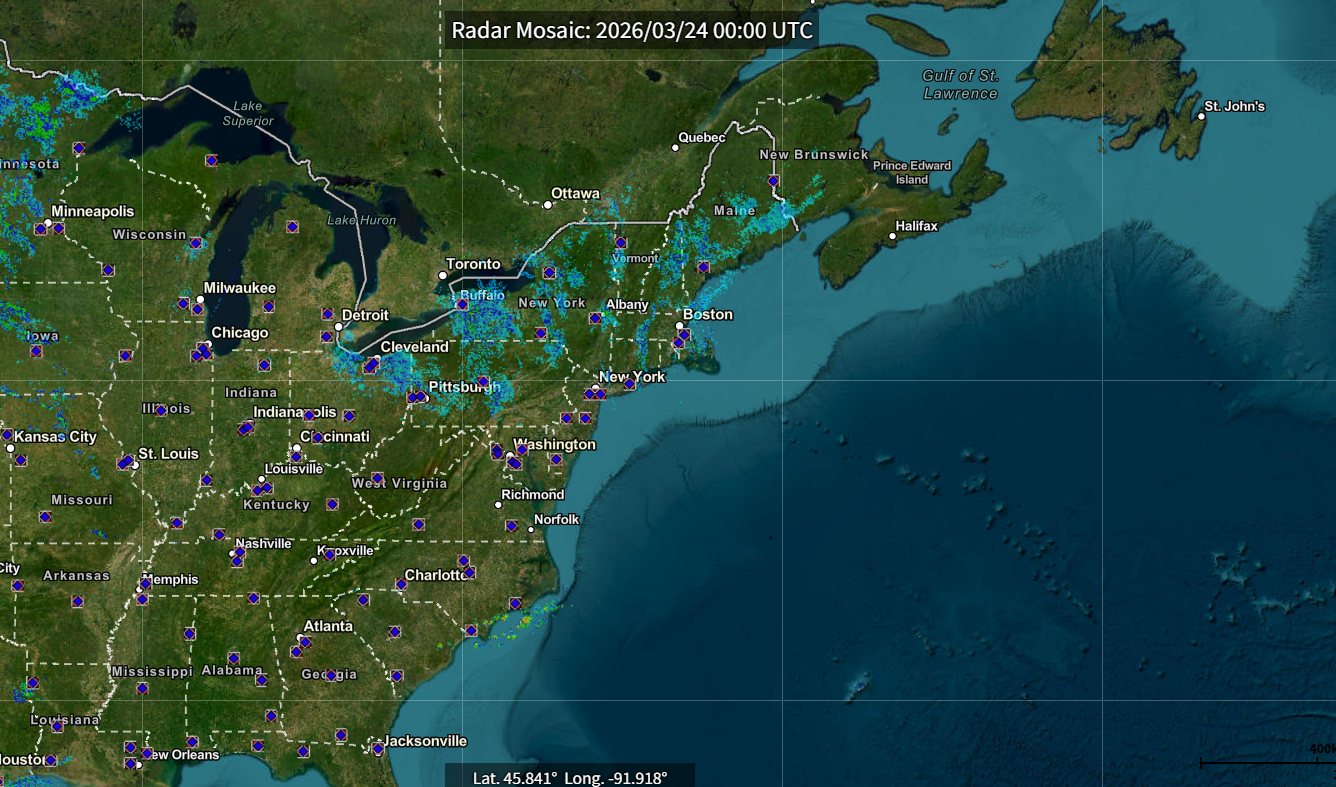

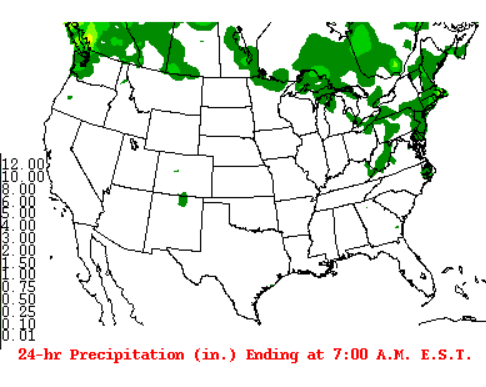

In [4]:
from IPython.display import Image, display

display(Image(filename="Map 1 473.png"))
display(Image(filename="Map 2 473.png"))
display(Image(filename="Map 3 473.png"))

In [5]:
#import all of the packages

from herbie import FastHerbie
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

In [6]:
#dataset from other notebook, so we don't have to keep running it
ds_a = xr.open_dataset("ecmwf_20260323.nc")
ds_b = xr.open_dataset("ecmwf_20260323Mar.nc")
ds2 = xr.merge([ds_a, ds_b], compat = 'override')
ds2

sh: 1: getfattr: not found
sh: 1: getfattr: not found


<xarray.Dataset> Size: 80kB
Dimensions:            (valid_time: 15, latitude: 11, longitude: 24)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 120B 2026-03-23 ... 2026-0...
  * latitude           (latitude) float64 88B 42.25 42.0 41.75 ... 40.0 39.75
  * longitude          (longitude) float64 192B -80.5 -80.25 ... -75.0 -74.75
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 120B ...
    heightAboveGround  float64 8B ...
    surface            float64 8B ...
Data variables:
    fg10               (valid_time, latitude, longitude) float32 16kB ...
    tp                 (valid_time, latitude, longitude) float32 16kB ...
    sf                 (valid_time, latitude, longitude) float32 16kB ...
    t2m                (valid_time, latitude, longitude) float32 16kB ...
    d2m                (valid_time, latitude, longitude) float32 16kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-01T17:12 GRIB to CDM+CF via cfgrib-0.9.1...

In [7]:
temp=ds2['t2m'] #variable for temperature from the data set
snow=ds2['sf'] #variable for snowfall from the data set
dew=ds2['d2m'] #variable for dew point temperature from the data set
wind_gust=ds2['fg10'] #variable for wind gusts from the data set
precip=ds2['tp'] #variable for total precip from the data set
 

In [8]:
import numpy as np
import matplotlib.pyplot as plt


# 1. VARIABLES

#unit conversions
temp_F = (temp - 273.15) * 9/5 + 32
dew_F = (dew - 273.15) * 9/5 + 32
precip_mm = precip * 1000
wind_mph = wind_gust * 2.237
snow_mm = snow * 1000
times = ds2['valid_time'].values

#Relavtive Humidity Def: 
def calc_rh(T, Td):
    return 100 * np.exp((17.625 * Td)/(243.04 + Td)) / np.exp((17.625 * T)/(243.04 + T))

#Wet Bulb Def: 
def wet_bulb_temp(T, RH):
    return T * np.arctan(0.151977 * (RH + 8.313659)**0.5) + \
           np.arctan(T + RH) - np.arctan(RH - 1.676331) + \
           0.00391838 * RH**1.5 * np.arctan(0.023101 * RH) - 4.686035

def wbgt_calc(T, Tw):
    return 0.7 * Tw + 0.3 * T


In [9]:

# Store results
precip_risk = []
wind_risk = []
wbgt_risk = []
field_risk = []

times = ds2['valid_time'].values #variable for valid times

for t in range(len(times)):

    T = temp_F.isel(valid_time=t) #finding the valid times for each variable for the sake of the hazard
    Td = dew_F.isel(valid_time=t)
    P = precip_mm.isel(valid_time=t)
    S = snow_mm.isel(valid_time=t)
    W = wind_mph.isel(valid_time=t)

    total = T.size #size of the data collection

 
    # WBGT
    
    RH = calc_rh(T, Td)
    Tw = wet_bulb_temp(T, RH)
    WBGT = wbgt_calc(T, Tw)

    wbgt_low25 = (WBGT <= 25).sum() / total * 100 #hazard level for wet bulb
    wbgt_low32 = (WBGT <= 32).sum() / total * 100

    if wbgt_low25 > 75: 
        wbgt_risk.append(100)
    elif wbgt_low25 >= 40 or wbgt_low32 > 75:
        wbgt_risk.append(60)
    else:
        wbgt_risk.append(20)

   
    # FIELD CONDITIONS
   
    heavy_precip = (P >= 5).sum() / total * 100 #same thing but for precip
    any_precip = (P >= 0.5).sum() / total * 100
    snow_cover = (S >= 2).sum() / total * 100

    freezing = (T <= 32).sum() / total * 100

    if snow_cover > 50 or heavy_precip > 75:
        field_risk.append(100)
    elif any_precip > 40 or (snow_cover > 25 and freezing < 50):
        field_risk.append(60)
    else:
        field_risk.append(20)

   
    # PRECIP

    heavy = (P >= 5).sum() / total * 100
    moderate = (P >= 2).sum() / total * 100

    if heavy > 75:
        precip_risk.append(100)
    elif moderate >= 40:
        precip_risk.append(60)
    else:
        precip_risk.append(20)

    
    # WIND
    
    strong = (W >= 15).sum() / total * 100

    if strong > 75:
        wind_risk.append(100)
    elif strong >= 40:
        wind_risk.append(60)
    else:
        wind_risk.append(20)



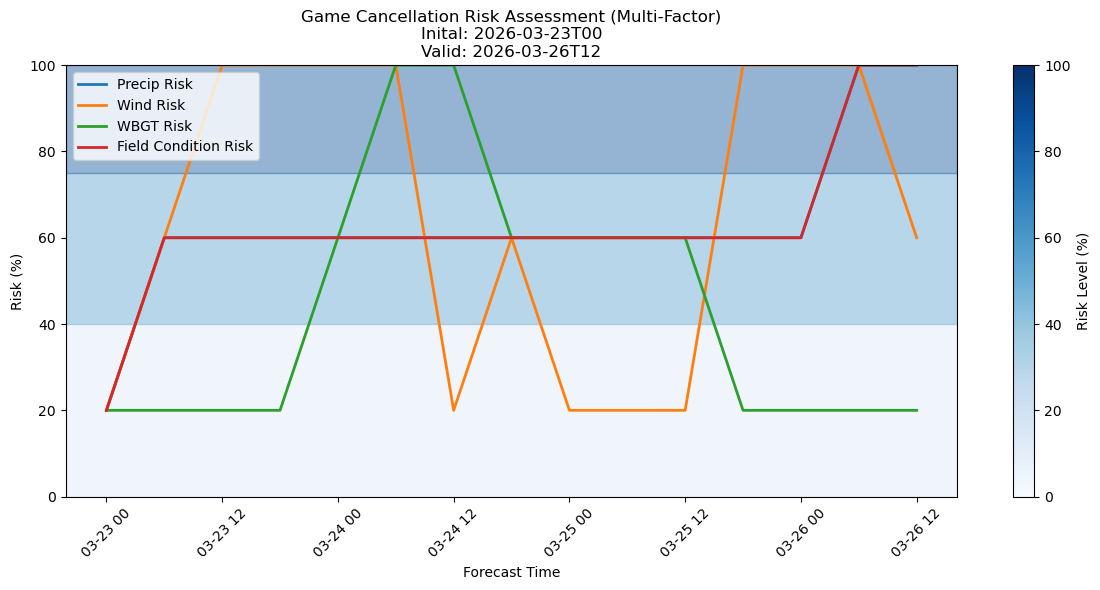

In [10]:
# 3. PLOT


fig, ax = plt.subplots(figsize=(12,6))

ax.plot(times, precip_risk, label='Precip Risk', linewidth=2) #plotting each variable by itself, but on the same graph
ax.plot(times, wind_risk, label='Wind Risk', linewidth=2)
ax.plot(times, wbgt_risk, label='WBGT Risk', linewidth=2)
ax.plot(times, field_risk, label='Field Condition Risk', linewidth=2)

# Overall max risk (decision line)
#overall = np.maximum.reduce([precip_risk, wind_risk, wbgt_risk, field_risk])
#ax.plot(times, overall, color='black', linewidth=3, linestyle='--', label='Overall Risk')

# Risk bands
ax.axhspan(75, 100, alpha=0.2)
ax.axhspan(40, 75, alpha=0.1)

ax.set_ylim(0, 100)
ax.set_ylabel('Risk (%)')
ax.set_xlabel('Forecast Time')
ax.set_title(
    f"Game Cancellation Risk Assessment (Multi-Factor)\n"
    f"Inital: {np.datetime_as_string(ds2['time'], unit='h')}\n"
    f"Valid: {np.datetime_as_string(ds2['valid_time'].values[-1], unit='h')}"
)

ax.legend()
plt.xticks(rotation=45)
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# Create normalization (0–100%)
norm = Normalize(vmin=0, vmax=100)

# Blue colormap
cmap = cm.Blues

# Create a ScalarMappable for the colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# Add background shading using same cmap
ax.axhspan(0, 40, color=cmap(norm(20)), alpha=0.3)
ax.axhspan(40, 75, color=cmap(norm(60)), alpha=0.3)
ax.axhspan(75, 100, color=cmap(norm(90)), alpha=0.3)

# Add colorbar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Risk Level (%)')

plt.tight_layout()
plt.show()


In [11]:
# ------------------------------------------
# 1. PREP TIME + SPATIAL AVERAGES
# ------------------------------------------

times = ds2['valid_time'].values

temp_series = ds2['t2m'].mean(dim=['latitude','longitude']) - 273.15  # °C
dew_series = ds2['d2m'].mean(dim=['latitude','longitude']) - 273.15   # °C
wind_series = ds2['fg10'].mean(dim=['latitude','longitude'])          # m/s
precip_series = ds2['tp'].mean(dim=['latitude','longitude']) * 1000   # mm
snow_series = ds2['sf'].mean(dim=['latitude','longitude']) * 1000     # mm

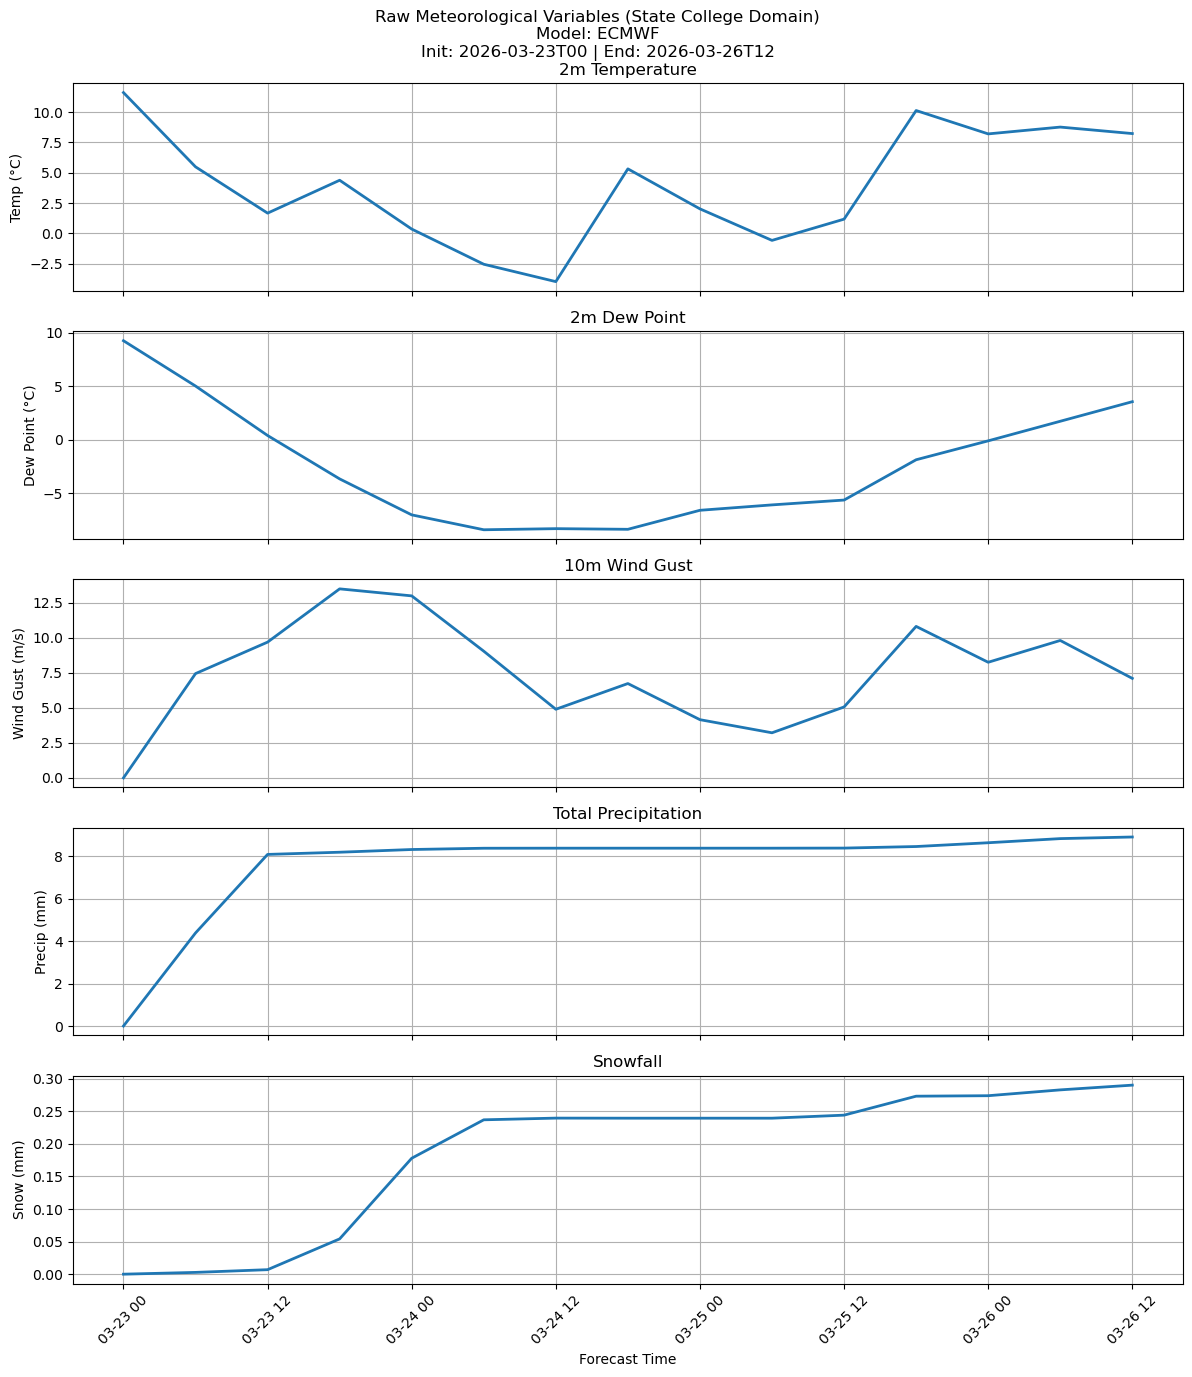

In [12]:

# ------------------------------------------
# 2. CREATE SUBPLOTS
# ------------------------------------------

fig, axs = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

# Temperature
axs[0].plot(times, temp_series, linewidth=2)
axs[0].set_ylabel('Temp (°C)')
axs[0].set_title('2m Temperature')

# Dew Point
axs[1].plot(times, dew_series, linewidth=2)
axs[1].set_ylabel('Dew Point (°C)')
axs[1].set_title('2m Dew Point')

# Wind Gust
axs[2].plot(times, wind_series, linewidth=2)
axs[2].set_ylabel('Wind Gust (m/s)')
axs[2].set_title('10m Wind Gust')

# Precipitation
axs[3].plot(times, precip_series, linewidth=2)
axs[3].set_ylabel('Precip (mm)')
axs[3].set_title('Total Precipitation')

# Snowfall
axs[4].plot(times, snow_series, linewidth=2)
axs[4].set_ylabel('Snow (mm)')
axs[4].set_title('Snowfall')

# ------------------------------------------
# 3. FORMATTING
# ------------------------------------------

axs[-1].set_xlabel('Forecast Time')

for ax in axs:
    ax.grid(True)

plt.suptitle(
    f"Raw Meteorological Variables (State College Domain)\n"
    f"Model: ECMWF\n"
    f"Init: {np.datetime_as_string(ds2['time'], unit='h')} | "
    f"End: {np.datetime_as_string(ds2['valid_time'].values[-1], unit='h')}"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ------------------------------------------
# 1. REGION (Pennsylvania)
# ------------------------------------------

lat_min, lat_max = 39.5, 42.5
lon_min, lon_max = -80.5, -74.5

# ------------------------------------------
# 2. SELECT FINAL TIME STEP
# ------------------------------------------

time_sel = ds2['valid_time'].values[-1]

tp = ds2['tp'].sel(valid_time=time_sel) * 1000      # mm
fg10 = ds2['fg10'].sel(valid_time=time_sel) * 2.237 # mph
t2m = ds2['t2m'].sel(valid_time=time_sel) - 273.15  # °C
d2m = ds2['d2m'].sel(valid_time=time_sel) - 273.15  # °C
sf = ds2['sf'].sel(valid_time=time_sel) * 1000      # mm


In [14]:


# ------------------------------------------
# WBGT CALCULATION
# ------------------------------------------

# Convert to Celsius if not already
T = t2m  # already in °C
Td = d2m # already in °C

# Approximate relative humidity
RH = 100 * (np.exp((17.625 * Td)/(243.04 + Td)) /
            np.exp((17.625 * T)/(243.04 + T)))

# Stull (2011) approximation for wet bulb temperature
Tw = T * np.arctan(0.151977 * np.sqrt(RH + 8.313659)) + \
     np.arctan(T + RH) - \
     np.arctan(RH - 1.676331) + \
     0.00391838 * RH**(3/2) * np.arctan(0.023101 * RH) - 4.686035

# WBGT approximation
wbgt = 0.7 * Tw + 0.3 * T

lons = ds2['longitude'].values
lats = ds2['latitude'].values
LON, LAT = np.meshgrid(lons, lats)

# ------------------------------------------
# 3. STORE VARIABLES
# ------------------------------------------

vars_list = [tp, fg10, t2m, d2m, sf, wbgt]
titles = [
    'Total Precipitation (mm)',
    'Wind Gust (mph)',
    'Temperature (°C)',
    'Dew Point (°C)',
    'Snowfall (mm)',
    'WBGT (°C)'
]


# ------------------------------------------
# CUSTOM WBGT COLORMAP
# ------------------------------------------

wbgt_colors = [
    (0.85, 0.95, 1.0),   # light blue (low stress)
    (0.6, 0.85, 0.6),    # green (safe)
    (1.0, 1.0, 0.6),     # yellow (caution)
    (1.0, 0.7, 0.2),     # orange (high risk)
    (0.8, 0.1, 0.1)      # red (extreme)
]

wbgt_cmap = LinearSegmentedColormap.from_list(
    "wbgt_custom", wbgt_colors, N=256
)
cmaps = ['Blues', 'Oranges', 'coolwarm', 'Greens', 'Purples', wbgt_cmap]


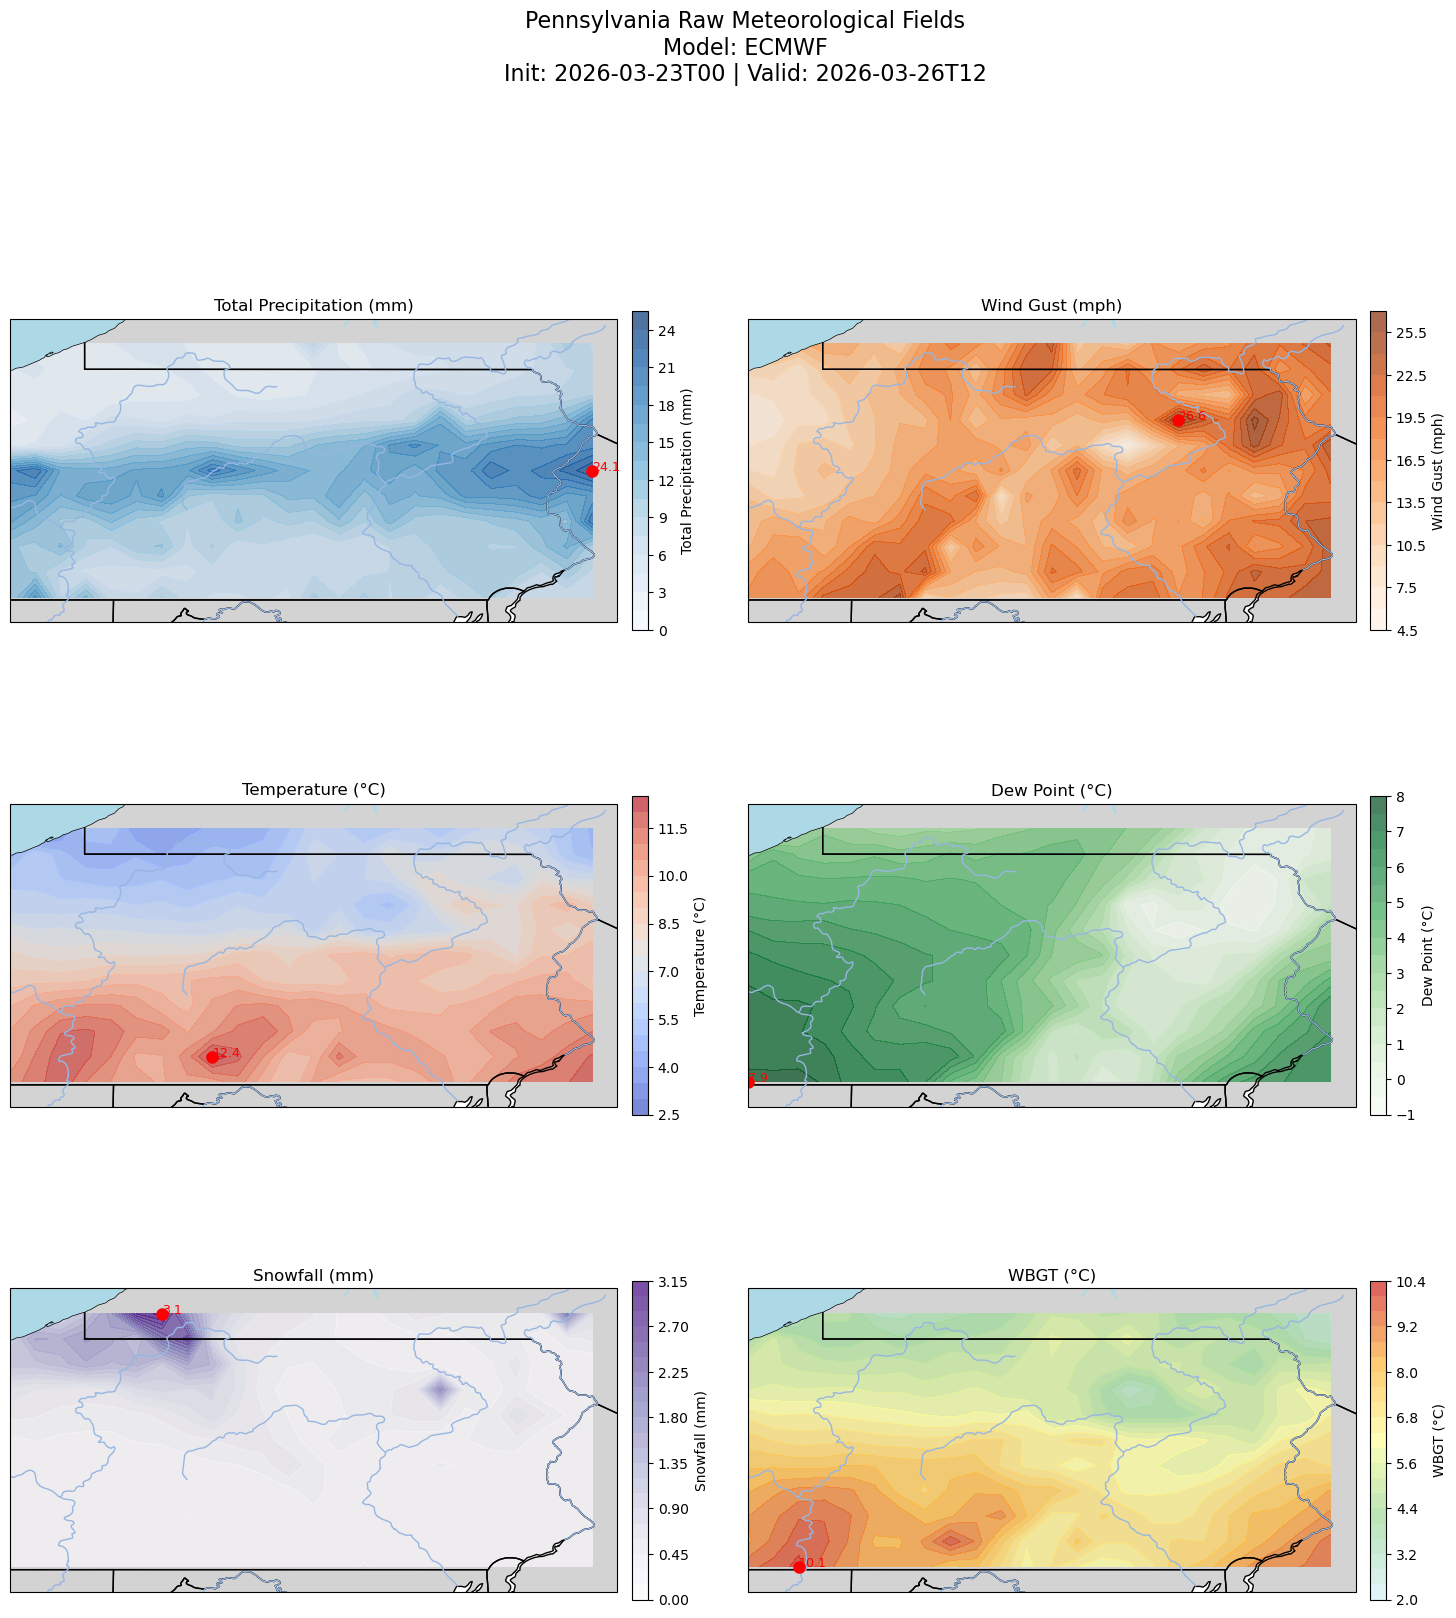

In [15]:
# ------------------------------------------
# 4. PLOTTING
# ------------------------------------------

fig, axes = plt.subplots(3, 2, figsize=(15, 18),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (ax, var, title, cmap) in enumerate(zip(axes, vars_list, titles, cmaps)):

    ax.set_extent([lon_min, lon_max, lat_min, lat_max])

    # Map features
    ax.add_feature(cfeature.STATES, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.LAKES, facecolor='lightblue')
    ax.add_feature(cfeature.RIVERS)

    # Convert to numpy
    data = var.values

    # Filled contour
    c = ax.contourf(LON, LAT, data, cmap=cmap, levels=20, alpha=0.7)

    # ------------------------------------------
    # FIND AND PLOT MAX LOCATION
    # ------------------------------------------
    max_idx = np.unravel_index(np.nanargmax(data), data.shape)
    max_lat = LAT[max_idx]
    max_lon = LON[max_idx]
    max_val = data[max_idx]

    ax.plot(max_lon, max_lat, 'ro', markersize=8)
    ax.text(max_lon, max_lat,
            f"{max_val:.1f}",
            color='red', fontsize=9, ha='left')

    # Colorbar
    cb = plt.colorbar(c, ax=ax, orientation='vertical', pad=0.02, shrink=0.5)
    cb.set_label(title)

    ax.set_title(title)



# ------------------------------------------
# 5. TITLE
# ------------------------------------------

fig.suptitle(
    f"Pennsylvania Raw Meteorological Fields\n"
    f"Model: ECMWF\n"
    f"Init: {np.datetime_as_string(ds2['time'].values, unit='h')} | "
    f"Valid: {np.datetime_as_string(time_sel, unit='h')}",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Group Contributions

Code below for number 5 comes from Ivan, over looked and comments by Flip and Michael

# Early Index Design 

We will use a 0-100% system

## Precipitation
##### HIGH RISK (>75%)
- High Confidence of heavy precipitation during activities.
- Significant risk of snow squalls or potential blizzard conditions.
##### MEDIUM RISK (40-75%)
- Medium Confidence of any precipitation during activities. This could be for any intensity of precipitation.
- Expected light precipitation during the entire activity period. Not immediately a safety risk, but could mess up the field. Tied with low temperatures and wind, this could pose a safety risk with long exposure. 
##### LOW RISK (<= 39%)
- No threat of precipitation during activities.


## Wet Bulb Globe Temperature

##### HIGH RISK (>75%)
- High Confidence of WBGTs below 25°F.
##### MEDIUM RISK (40-75%)
- Medium Confidence of WBGTs below 25°F.
- High Confidence of WBGTs below 32°F but above 25°F.
##### LOW RISK (<= 39%)
No threat.
Medium-high confidence of WBGTs above 32°F.

## Winds

##### HIGH RISK (>75%)
- High Confidence of sustained winds above 15mph with a temperature at 35°F.
- High Confidence of any wind with any temperatures below freezing.
##### MEDIUM RISK (40-75%)
- Medium Confidence of a wind that would result in a wind chill temperature below 25°F (see chart below). 
- High confidence of intermittent gusts with temperatures below freezing.
##### LOW RISK (<= 39%)
- No threat. 
 
## Field Conditions

##### HIGH RISK
- Recent accumulated snow or ice.
- Heavy liquid precipitation during the day.
- Recent rain, sleet, or freezing rain with temperatures falling below freezing afterwards and staying below freezing until beginning of activities (ice risk, slip and fall).
##### MEDIUM RISK
- Recent light precipitation of any type with a relatively long duration. Light rain throughout the entire day could result in muddy or unsafe field conditions. 
- Recent snow followed by above freezing temperatures that could lead to a muddy surface (slip and fall risk).
- Wintery mix expected during the activity period.
##### LOW RISK
- No recent precipitation that would impact the field.
